# 🔗 Módulo 2.2: Modelos Lineales
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 10 horas

---

## 🎯 Objetivos del Módulo

Los modelos lineales son la base del Machine Learning. Son interpretables, eficientes y la base de muchos algoritmos más complejos. En este módulo, dominarás las técnicas lineales tanto para regresión como para clasificación.

Al finalizar, serás capaz de:

- ✅ Implementar y entender la **Regresión Lineal Múltiple** para predecir valores a partir de múltiples características.
- ✅ Utilizar la **Regresión Logística** como un potente y fundamental modelo de clasificación.
- ✅ Comprender el concepto de **Regularización** como una técnica clave para combatir el overfitting.
- ✅ Aplicar la regularización **Ridge (L2)** y **Lasso (L1)** para crear modelos más robustos.
- ✅ Interpretar los coeficientes de los modelos lineales para extraer conclusiones de negocio.

**¡Prepárate para construir modelos que no solo predicen, sino que también explican!**

---

## 📚 Tabla de Contenidos

1. [Regresión Lineal Múltiple](#1-reg-multiple)
   - [Más Allá de una Sola Variable](#1.1-mas-alla)
   - [Implementación y Análisis de Coeficientes](#1.2-implementacion)
2. [Regresión Logística para Clasificación](#2-reg-logistica)
   - [De la Línea a la Probabilidad: La Función Sigmoide](#2.1-sigmoide)
   - [Implementación y Toma de Decisiones](#2.2-implementacion-log)
3. [El Problema del Overfitting en Modelos Lineales](#3-overfitting)
   - [Cuando los Coeficientes se Vuelven Locos: Multicolinealidad](#3.1-multi)
4. [Regularización: Domando la Complejidad](#4-regularizacion)
   - [La Idea: Penalizar la Complejidad](#4.1-idea)
   - [Regresión Ridge (Regularización L2)](#4.2-ridge)
   - [Regresión Lasso (Regularización L1)](#4.3-lasso)
   - [Comparativa: Ridge vs. Lasso](#4.4-comparativa)
5. [Resumen y Próximos Pasos](#5-resumen)

---

## 🏡 1. Regresión Lineal Múltiple <a id='1-reg-multiple'></a>

### 1.1 Más Allá de una Sola Variable <a id='1.1-mas-alla'></a>

En el módulo anterior, predijimos el precio de una casa basándonos solo en su tamaño. Pero en el mundo real, el precio depende de muchos más factores: número de habitaciones, antigüedad, ubicación, etc.

La **Regresión Lineal Múltiple** extiende la regresión lineal simple para incorporar múltiples variables predictoras (características).

**Ecuación del Modelo:**
$$ \text{Precio} = \beta_0 + \beta_1 \times \text{Tamaño} + \beta_2 \times \text{Nº Habitaciones} + \beta_3 \times \text{Antigüedad} + \dots + \epsilon $$

- **β₀**: Es el intercepto, el precio base si todas las demás características fueran cero.
- **β₁, β₂, β₃...**: Son los **coeficientes** del modelo. Cada `βᵢ` representa el cambio en el precio por cada unidad de aumento en la característica `i`, **manteniendo todas las demás constantes**.

La interpretación de estos coeficientes es extremadamente útil para entender qué factores influyen más en el resultado.

🏠 IMAGINEMOS QUE QUEREMOS PREDECIR EL PRECIO DE UNA CASA

🔹 REGRESIÓN LINEAL SIMPLE (1 variable):
   Solo mirábamos el TAMAÑO de la casa
   Precio = ? + (algo × Tamaño)
   ❌ Pero... ¿y si la casa tiene muchas habitaciones?
   ❌ ¿Y si es muy antigua?

🔹 REGRESIÓN LINEAL MÚLTIPLE (varias variables):
   Ahora miramos VARIOS factores a la vez:
   • Tamaño (m²)
   • Número de habitaciones
   • Antigüedad (años)
   ✅ ¡Mucho más realista!

🧮 LOS INGREDIENTES DE LA FÓRMULA


📌 INTERCEPTO (β₀):
   • Es el 'precio base' de partida
   • Imagina una casa hipotética con:
     - 0 m² (no existe, pero matemáticamente...)
     - 0 habitaciones
     - 0 años de antigüedad
   • Es el punto de partida antes de añadir las características
   • Ejemplo: β₀ = 10,000€


📌 COEFICIENTES (β₁, β₂, β₃...):
   • Son los 'multiplicadores' de cada característica
   • Nos dicen: ¿cuánto SUBE o BAJA el precio por cada unidad?

   🔸 β₁ (coeficiente del tamaño) = 1,200
      → Por cada m² adicional, el precio sube 1,200€
      → Si la casa tiene 100 m², añade: 100 × 1,200 = 120,000€

   🔸 β₂ (coeficiente de habitaciones) = 5,000
      → Por cada habitación extra, el precio sube 5,000€
      → Si tiene 3 habitaciones, añade: 3 × 5,000 = 15,000€

   🔸 β₃ (coeficiente de antigüedad) = -300
      → Por cada año de antigüedad, el precio BAJA 300€
      → Si tiene 20 años, resta: 20 × 300 = -6,000€
      → ⚠️ El signo NEGATIVO significa que reduce el precio


🧪 EJEMPLO COMPLETO

🏡 Casa con:
   • Tamaño: 120 m²
   • Habitaciones: 3
   • Antigüedad: 15 años

💰 Cálculo del precio:
   Precio base (intercepto):            10,000€
   + Tamaño (120 × 1200):         144,000€
   + Habitaciones (3 × 5000):       15,000€
   - Antigüedad (15 × 300):           -4,500€
   ----------------------------------------
   PRECIO TOTAL ESTIMADO:              164,500€


🎯 CONCLUSIÓN CLAVE

La Regresión Lineal Múltiple es como una RECETA DE COCINA:

🥣 Ingrediente base (intercepto): empiezas con un precio base
➕ Ingredientes que SUMAN (coeficientes positivos): cada m² y habitación
➖ Ingredientes que RESTAN (coeficientes negativos): la antigüedad

El modelo aprende automáticamente cuánto vale cada ingrediente
analizando cientos de casas reales. ¡Así puede predecir precios nuevos!

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Datos sintéticos de precios de casas con más características
np.random.seed(42)
n_samples = 200
tamaño = np.random.randint(60, 250, n_samples)
habitaciones = np.random.randint(1, 6, n_samples)
antiguedad = np.random.randint(0, 50, n_samples)

# El precio depende de las 3 características + ruido
precio = 10000 + (tamaño * 1200) + (habitaciones * 5000) - (antiguedad * 300) + np.random.normal(0, 20000, n_samples)

df_casas = pd.DataFrame({
    'tamaño': tamaño,
    'habitaciones': habitaciones,
    'antiguedad': antiguedad,
    'precio': precio
})

print("Datos de ejemplo:")
display(df_casas.head())

### 1.2 Implementación y Análisis de Coeficientes <a id='1.2-implementacion'></a>

In [ ]:
# 1. Definir X e y
X = df_casas[['tamaño', 'habitaciones', 'antiguedad']]
y = df_casas['precio']

# 2. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# 4. Evaluar el modelo
y_pred = model_multi.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}€")
print(f"R²: {r2:.2f}")

# 5. Interpretar los coeficientes
coeficientes = pd.DataFrame(model_multi.coef_, X.columns, columns=['Coeficiente'])
print("\n--- Interpretación de Coeficientes ---")
display(coeficientes)

print(f"\nIntercepto (Precio base): {model_multi.intercept_:.2f}€")

**Análisis de los resultados:**

- **tamaño**: Por cada m² adicional, el precio aumenta en ~1200€, manteniendo lo demás constante.
- **habitaciones**: Por cada habitación adicional, el precio aumenta en ~5000€, manteniendo lo demás constante.
- **antiguedad**: Por cada año de antigüedad, el precio *disminuye* en ~300€, manteniendo lo demás constante.

Esta información es increíblemente valiosa para el negocio. Podemos cuantificar el impacto de cada característica.

---

### 2.2 Implementación Práctica de la Función Sigmoide <a id='2.2-implementacion-log'></a>

#### 🎯 Objetivo
Entender cómo la función sigmoide transforma una predicción lineal en una probabilidad.

#### 🧮 Paso 1: Entender la Función Sigmoide

La función sigmoide (función logística) es:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

Donde:
- **z**: Es la salida de la regresión lineal: $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots$
- **σ(z)**: Es la probabilidad predicha (siempre entre 0 y 1)

#### 🔍 Propiedades Clave de la Sigmoide:

| Entrada (z) | Salida σ(z) | Interpretación |
|:---|:---|:---|
| z → -∞ | σ(z) → 0 | Predicción muy negativa = 0% probabilidad |
| z = -5 | σ(z) ≈ 0.007 | Casi imposible (0.7%) |
| z = 0 | σ(z) = 0.5 | Punto de decisión (50%) |
| z = 5 | σ(z) ≈ 0.993 | Casi seguro (99.3%) |
| z → +∞ | σ(z) → 1 | Predicción muy positiva = 100% probabilidad |

#### ✨ Intuición Visual

```
          Probabilidad
              ↑
            1 │         ╱╱╱╱
              │        ╱╱  (z = 0, p = 0.5)
            0.5│      ╱╱
              │     ╱
              │    ╱
            0 │___________________→ z
           -10  -5   0   5   10
           
La curva en S (sigmoide) transforma cualquier z en [0,1]
```

#### 🔄 De Predicción Lineal a Probabilidad

**PASO 1: Predicción Lineal**
```
z = 0.5 + 2×edad - 1×riesgo
```

**PASO 2: Aplicar Sigmoide**
```
P(Churn=1) = σ(z) = 1/(1 + e^(-z))
```

**PASO 3: Tomar Decisión**
```
Si P > 0.5 → Predicción = CHURN (1)
Si P ≤ 0.5 → Predicción = NO CHURN (0)
```

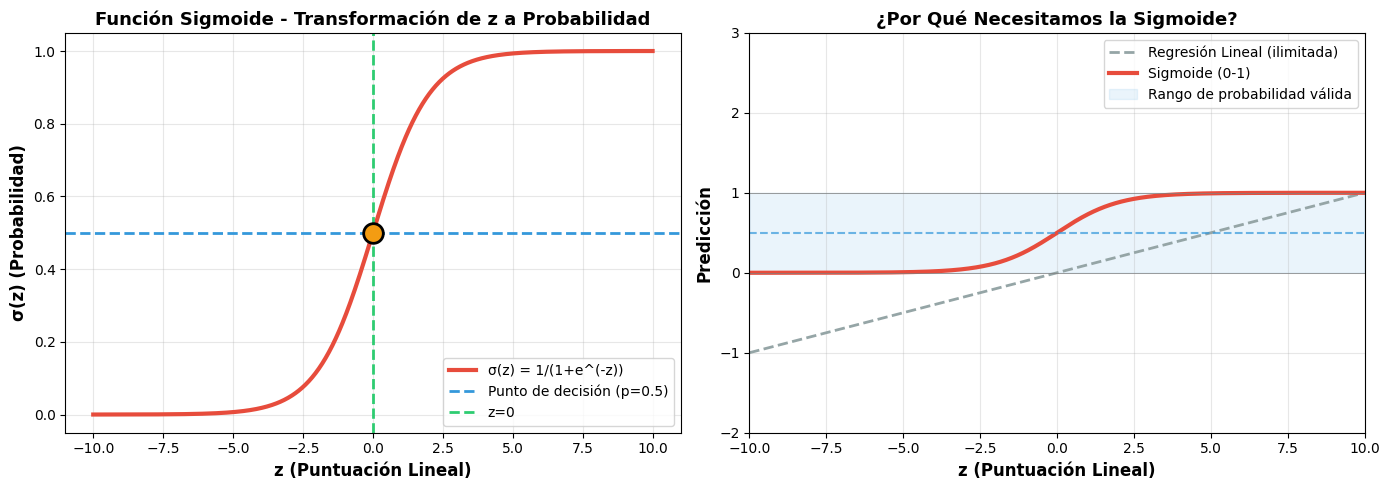

✅ La sigmoide garantiza que SIEMPRE obtenemos probabilidades entre 0 y 1


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # Función sigmoide optimizada

# Crear valores de z
z = np.linspace(-10, 10, 1000)

# Calcular la sigmoide usando dos métodos
# Método 1: Implementación manual
sigmoid_manual = 1 / (1 + np.exp(-z))

# Método 2: Usando scipy (más estable numéricamente)
sigmoid_scipy = expit(z)

# Crear la visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: La función sigmoide
ax1 = axes[0]
ax1.plot(z, sigmoid_scipy, linewidth=3, color='#e74c3c', label='σ(z) = 1/(1+e^(-z))')
ax1.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2, label='Punto de decisión (p=0.5)')
ax1.axvline(x=0, color='#2ecc71', linestyle='--', linewidth=2, label='z=0')
ax1.scatter([0], [0.5], color='#f39c12', s=200, zorder=5, edgecolors='black', linewidth=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z (Puntuación Lineal)', fontsize=12, fontweight='bold')
ax1.set_ylabel('σ(z) (Probabilidad)', fontsize=12, fontweight='bold')
ax1.set_title('Función Sigmoide - Transformación de z a Probabilidad', fontsize=13, fontweight='bold')
ax1.set_ylim([-0.05, 1.05])
ax1.legend(fontsize=10, loc='lower right')

# Gráfico 2: Comparación Lineal vs Sigmoide
ax2 = axes[1]
# Regresión lineal normal (sin restricción)
z_linear = 0.1 * z  # Una línea con pendiente 0.1
ax2.plot(z, z_linear, linewidth=2, color='#95a5a6', label='Regresión Lineal (ilimitada)', linestyle='--')
ax2.plot(z, sigmoid_scipy, linewidth=3, color='#e74c3c', label='Sigmoide (0-1)')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=1, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.fill_between(z, 0, 1, alpha=0.1, color='#3498db', label='Rango de probabilidad válida')
ax2.set_xlabel('z (Puntuación Lineal)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicción', fontsize=12, fontweight='bold')
ax2.set_title('¿Por Qué Necesitamos la Sigmoide?', fontsize=13, fontweight='bold')
ax2.set_ylim([-2, 3])
ax2.set_xlim([-10, 10])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ La sigmoide garantiza que SIEMPRE obtenemos probabilidades entre 0 y 1")

In [9]:
# Función sigmoide personalizada para entender paso a paso
def sigmoide(z):
    """
    Calcula la función sigmoide de forma segura.
    
    Parámetros:
    -----------
    z : float o np.array
        Valor(es) de entrada (puntuación lineal)
    
    Retorna:
    --------
    float o np.array
        Probabilidad entre 0 y 1
    """
    # Usamos clip para evitar overflow en valores muy grandes/pequeños
    z_safe = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_safe))

print("=" * 70)
print("EJEMPLO: Predicción de Churn para UN Cliente")
print("=" * 70)

# Parámetros del modelo (supuestos)
beta_0 = -0.5  # Intercepto
beta_1 = 0.02  # Coeficiente de antigüedad
beta_2 = 0.03  # Coeficiente de gasto_mensual

# Datos del cliente
antiguedad = 24  # meses
gasto_mensual = 50  # euros

# Paso 1: Calcular z (predicción lineal)
z = beta_0 + beta_1 * antiguedad + beta_2 * gasto_mensual
print(f"\n📊 PASO 1: Calcular Puntuación Lineal (z)")
print(f"   z = β₀ + β₁×antiguedad + β₂×gasto")
print(f"   z = {beta_0} + {beta_1}×{antiguedad} + {beta_2}×{gasto_mensual}")
print(f"   z = {z:.4f}")

# Paso 2: Aplicar sigmoide
probabilidad_churn = sigmoide(z)
print(f"\n🔄 PASO 2: Aplicar Sigmoide σ(z)")
print(f"   P(Churn=1) = 1 / (1 + e^(-z))")
print(f"   P(Churn=1) = 1 / (1 + e^(-{z:.4f}))")
print(f"   P(Churn=1) = {probabilidad_churn:.4f}")

# Paso 3: Tomar decisión
prediccion = 1 if probabilidad_churn > 0.5 else 0
print(f"\n🎯 PASO 3: Tomar Decisión")
print(f"   Umbral: 0.5")
print(f"   Probabilidad: {probabilidad_churn:.1%}")
if probabilidad_churn > 0.5:
    print(f"   ✅ PREDICCIÓN: CHURN (abandono cliente)")
else:
    print(f"   ✅ PREDICCIÓN: NO CHURN (mantiene cliente)")

EJEMPLO: Predicción de Churn para UN Cliente

📊 PASO 1: Calcular Puntuación Lineal (z)
   z = β₀ + β₁×antiguedad + β₂×gasto
   z = -0.5 + 0.02×24 + 0.03×50
   z = 1.4800

🔄 PASO 2: Aplicar Sigmoide σ(z)
   P(Churn=1) = 1 / (1 + e^(-z))
   P(Churn=1) = 1 / (1 + e^(-1.4800))
   P(Churn=1) = 0.8146

🎯 PASO 3: Tomar Decisión
   Umbral: 0.5
   Probabilidad: 81.5%
   ✅ PREDICCIÓN: CHURN (abandono cliente)



EJEMPLO: Predicción de Churn para VARIOS Clientes

Cliente  Antigüedad  Gasto    z  P(Churn) Predicción
      A           6     30 0.52  0.627148      CHURN
      B          12     50 1.24  0.775564      CHURN
      C          24     75 2.23  0.902911      CHURN
      D          36    100 3.22  0.961580      CHURN
      E          48    150 4.96  0.993036      CHURN


C:\Users\Jaf\AppData\Local\Temp\ipykernel_8628\1374769344.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


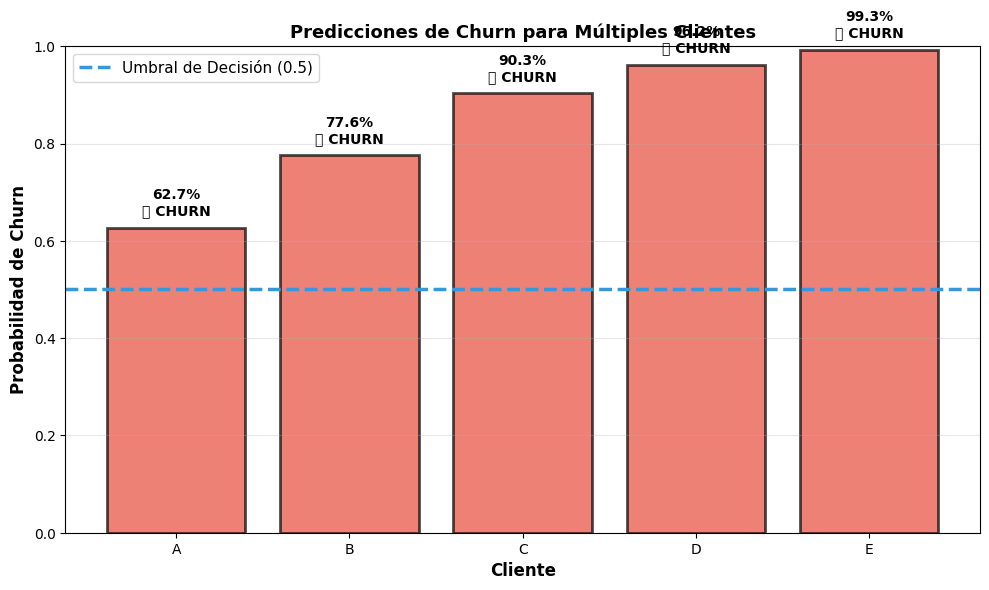


💡 LECCIONES CLAVE:
  1. La sigmoide GARANTIZA probabilidades entre 0 y 1
  2. A mayor z, mayor probabilidad de clase 1
  3. El umbral 0.5 es convencional pero se puede ajustar
  4. Probabilidades > 0.5 → Predicción = 1 (Churn)
  5. Probabilidades ≤ 0.5 → Predicción = 0 (No Churn)


In [10]:
print("\n" + "=" * 70)
print("EJEMPLO: Predicción de Churn para VARIOS Clientes")
print("=" * 70)

clientes_datos = {
    'Cliente': ['A', 'B', 'C', 'D', 'E'],
    'Antigüedad (meses)': [6, 12, 24, 36, 48],
    'Gasto Mensual (€)': [30, 50, 75, 100, 150]
}

resultados = []
for i in range(len(clientes_datos['Cliente'])):
    ant = clientes_datos['Antigüedad (meses)'][i]
    gasto = clientes_datos['Gasto Mensual (€)'][i]
    
    z_cliente = beta_0 + beta_1 * ant + beta_2 * gasto
    prob_cliente = sigmoide(z_cliente)
    pred_cliente = 1 if prob_cliente > 0.5 else 0
    
    resultados.append({
        'Cliente': clientes_datos['Cliente'][i],
        'Antigüedad': ant,
        'Gasto': gasto,
        'z': z_cliente,
        'P(Churn)': prob_cliente,
        'Predicción': 'CHURN' if pred_cliente == 1 else 'NO CHURN'
    })

# Mostrar tabla
df_predicciones = pd.DataFrame(resultados)
print("\n" + df_predicciones.to_string(index=False))

# Visualizar resultados
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e74c3c' if p > 0.5 else '#2ecc71' for p in df_predicciones['P(Churn)']]
barras = ax.bar(df_predicciones['Cliente'], df_predicciones['P(Churn)'], color=colores, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2.5, label='Umbral de Decisión (0.5)')
ax.set_ylabel('Probabilidad de Churn', fontsize=12, fontweight='bold')
ax.set_xlabel('Cliente', fontsize=12, fontweight='bold')
ax.set_title('Predicciones de Churn para Múltiples Clientes', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas en las barras
for i, (barra, prob) in enumerate(zip(barras, df_predicciones['P(Churn)'])):
    altura = barra.get_height()
    pred_text = '✅ CHURN' if prob > 0.5 else '✅ NO CHURN'
    ax.text(barra.get_x() + barra.get_width()/2., altura + 0.02,
            f'{prob:.1%}\n{pred_text}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 LECCIONES CLAVE:")
print("  1. La sigmoide GARANTIZA probabilidades entre 0 y 1")
print("  2. A mayor z, mayor probabilidad de clase 1")
print("  3. El umbral 0.5 es convencional pero se puede ajustar")
print("  4. Probabilidades > 0.5 → Predicción = 1 (Churn)")
print("  5. Probabilidades ≤ 0.5 → Predicción = 0 (No Churn)")

C:\Users\Jaf\AppData\Local\Temp\ipykernel_8628\4158875137.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jaf\AppData\Local\Temp\ipykernel_8628\4158875137.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


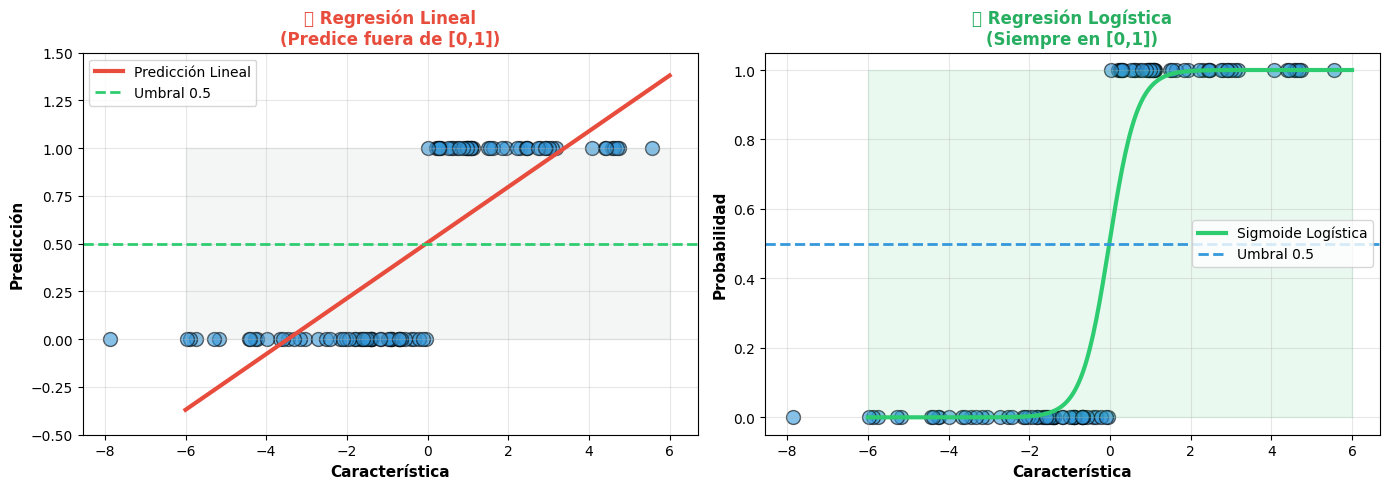

✨ DIFERENCIA CLAVE:
  • Regresión Lineal: Puede predecir valores < 0 o > 1
  • Regresión Logística: SIEMPRE predice probabilidades entre 0 y 1


In [11]:
from sklearn.linear_model import LinearRegression, LogisticRegression

# Crear datos de ejemplo
np.random.seed(42)
X_demo = np.random.randn(100, 1) * 3
y_demo = (X_demo.ravel() > 0).astype(int)  # Etiqueta binaria

# Entrenar ambos modelos
modelo_lineal = LinearRegression().fit(X_demo, y_demo)
modelo_logistico = LogisticRegression().fit(X_demo, y_demo)

# Generar predicciones para visualizar
X_range = np.linspace(-6, 6, 300).reshape(-1, 1)
y_lineal = modelo_lineal.predict(X_range)
y_logistico = modelo_logistico.predict_proba(X_range)[:, 1]

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Regresión Lineal
ax1 = axes[0]
ax1.scatter(X_demo, y_demo, alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=1)
ax1.plot(X_range, y_lineal, color='#e74c3c', linewidth=3, label='Predicción Lineal')
ax1.axhline(y=0.5, color='#2ecc71', linestyle='--', linewidth=2, label='Umbral 0.5')
ax1.fill_between(X_range.ravel(), 0, 1, alpha=0.1, color='#95a5a6')
ax1.set_xlabel('Característica', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicción', fontsize=11, fontweight='bold')
ax1.set_title('❌ Regresión Lineal\n(Predice fuera de [0,1])', fontsize=12, fontweight='bold', color='#e74c3c')
ax1.set_ylim([-0.5, 1.5])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2: Regresión Logística
ax2 = axes[1]
ax2.scatter(X_demo, y_demo, alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=1)
ax2.plot(X_range, y_logistico, color='#2ecc71', linewidth=3, label='Sigmoide Logística')
ax2.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2, label='Umbral 0.5')
ax2.fill_between(X_range.ravel(), 0, 1, alpha=0.1, color='#2ecc71')
ax2.set_xlabel('Característica', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
ax2.set_title('✅ Regresión Logística\n(Siempre en [0,1])', fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_ylim([-0.05, 1.05])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✨ DIFERENCIA CLAVE:")
print("  • Regresión Lineal: Puede predecir valores < 0 o > 1")
print("  • Regresión Logística: SIEMPRE predice probabilidades entre 0 y 1")

#### 🎓 Resumen Conceptual: ¿Por Qué Necesitamos la Sigmoide?

**1️⃣ Regresión Lineal sin restricciones**
   - Entrada: cualquier número
   - Salida: cualquier número (incluso -100 o +1000)
   - Problema: ¡No es una probabilidad válida!

**2️⃣ Sigmoide: La solución mágica**
   - Entrada: z (cualquier número real)
   - Salida: siempre entre 0 y 1 ✅
   - Interpretación: Probabilidad de la clase 1

**3️⃣ Cómo funciona la decisión**
   - Calcula: z = β₀ + β₁x₁ + β₂x₂ + ...
   - Transforma: p = σ(z) = 1/(1+e^(-z))
   - Decide: Si p > 0.5 → Clase 1, sino → Clase 0

**TABLA RÁPIDA DE LA SIGMOIDE**

| z     | σ(z)  | Interpretación |
|-------|-------|----------------|
| -10   | 0.00  | Casi seguro clase 0 |
| -5    | 0.01  | Muy probablemente clase 0 |
| 0     | 0.50  | Indeciso (50-50) |
| 5     | 0.99  | Muy probablemente clase 1 |
| 10    | 1.00  | Casi seguro clase 1 |

---

### 2.3 Implementación y Toma de Decisiones con scikit-learn

In [7]:
from sklearn.linear_model import LogisticRegression # Para clasificación
from sklearn.metrics import classification_report, confusion_matrix # Métricas de clasificación
from sklearn.preprocessing import StandardScaler # Escalado de características

# Reutilizamos los datos de Churn
np.random.seed(42)
data_churn = {
    'antiguedad': np.random.randint(1, 60, 200), # meses como cliente
    'gasto_mensual': np.random.uniform(20, 200, 200), # gasto mensual en euros
    'churn': np.random.randint(0, 2, 200) # 0 = no churn, 1 = churn
}
data_churn['churn'][:140] = 0 # Hacemos que haya más no churn
data_churn['churn'][140:] = 1 # para balancear un poco
df_churn = pd.DataFrame(data_churn).sample(frac=1, random_state=42).reset_index(drop=True) # Mezclamos los datos

X_churn = df_churn[['antiguedad', 'gasto_mensual']] # Características
y_churn = df_churn['churn'] # Etiqueta

# Es una buena práctica escalar los datos para modelos lineales
scaler = StandardScaler() # Escalador para estandarizar características
X_churn_scaled = scaler.fit_transform(X_churn) # Escalamos las características para churn

# Dividir los datos en entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_churn_scaled, y_churn, test_size=0.3, random_state=42, stratify=y_churn)

# Entrenar el modelo de Regresión Logística
log_model = LogisticRegression(random_state=42) # Crear el modelo
log_model.fit(X_train_c, y_train_c) # Entrenar el modelo

# Evaluar
y_pred_c = log_model.predict(X_test_c) # Predicciones
print("--- Reporte de Clasificación ---")
print(classification_report(y_test_c, y_pred_c)) # Métricas de clasificación

# Ver las probabilidades
probabilidades = log_model.predict_proba(X_test_c[:5]) # Probabilidades para las 5 primeras muestras
print("\n--- Probabilidades Predichas (No Churn, Churn) ---")
print(probabilidades)

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        42
           1       0.00      0.00      0.00        18

    accuracy                           0.70        60
   macro avg       0.35      0.50      0.41        60
weighted avg       0.49      0.70      0.58        60


--- Probabilidades Predichas (No Churn, Churn) ---
[[0.8032042  0.1967958 ]
 [0.83587596 0.16412404]
 [0.76453429 0.23546571]
 [0.73251256 0.26748744]
 [0.7666818  0.2333182 ]]


C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

---

## ⛓️ 3. El Problema del Overfitting en Modelos Lineales <a id='3-overfitting'></a>

Los modelos lineales también pueden sufrir de overfitting, especialmente cuando:
1.  Tenemos **muchas características** (alta dimensionalidad).
2.  Existe **multicolinealidad**.

### 3.1 Cuando los Coeficientes se Vuelven Locos: Multicolinealidad <a id='3.1-multi'></a>

La **multicolinealidad** ocurre cuando dos o más variables predictoras están altamente correlacionadas entre sí. 

**Ejemplo**: `tamaño_m2` y `tamaño_pies2`. Son esencialmente la misma información. 

**Problema**: Si las características están correlacionadas, el modelo no sabe a cuál de ellas atribuir el efecto. Esto hace que los coeficientes se vuelvan muy inestables y grandes, llevando a overfitting. El modelo se ajusta demasiado al ruido específico de los datos de entrenamiento.

La **Regularización** es la solución a este problema.

## 🧮 4. Regularización: Domando la Complejidad <a id='4-regularizacion'></a>

### 4.1 La Idea: Penalizar la Complejidad <a id='4.1-idea'></a>

La regularización añade una **penalización** a la función de coste del modelo. Esta penalización está relacionada con el **tamaño de los coeficientes**.

**Función de Coste Original (MSE):** $ \sum (y_i - \hat{y}_i)^2 $

**Función de Coste Regularizada:** $ \sum (y_i - \hat{y}_i)^2 + \alpha \times \text{Penalización}(\beta) $

- El modelo ahora tiene que hacer dos cosas: minimizar el error de predicción Y mantener los coeficientes pequeños.
- **α (alpha)**: Es un hiperparámetro que controla la **fuerza de la regularización**. 
  - Si α = 0, no hay regularización.
  - Si α es muy grande, los coeficientes se encogerán hacia cero.

Hay dos tipos principales de regularización: Ridge y Lasso.

### 4.2 Regresión Ridge (Regularización L2) <a id='4.2-ridge'></a>

Ridge añade una penalización igual a la **suma de los coeficientes al cuadrado**.

**Penalización L2:** $ \alpha \sum_{j=1}^{p} \beta_j^2 $

- **Efecto**: Encoge los coeficientes de las características menos importantes **hacia cero**, pero **nunca los hace exactamente cero**.
- **Cuándo usarla**: Es un buen punto de partida. Funciona bien en la mayoría de los casos y estabiliza el modelo.

In [ ]:
from sklearn.linear_model import Ridge

# Usaremos los datos de las casas, que tienen varias características
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos es MUY importante para la regularización
scaler_reg = StandardScaler()
X_train_scaled_r = scaler_reg.fit_transform(X_train_r)
X_test_scaled_r = scaler_reg.transform(X_test_r)

# Entrenar un modelo Ridge (alpha=1.0 por defecto)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_r, y_train_r)

# Comparar coeficientes con el modelo lineal simple
model_multi_scaled = LinearRegression().fit(X_train_scaled_r, y_train_r)

coefs = pd.DataFrame({
    'LinearRegression': model_multi_scaled.coef_,
    'Ridge': ridge_model.coef_
}, index=X.columns)

print("Comparación de Coeficientes (Datos Escalados):")
display(coefs)

Observa cómo los coeficientes del modelo Ridge son ligeramente más pequeños (más cercanos a cero) que los de la regresión lineal estándar. El modelo es más "conservador".

### 4.3 Regresión Lasso (Regularización L1) <a id='4.3-lasso'></a>

Lasso añade una penalización igual a la **suma del valor absoluto de los coeficientes**.

**Penalización L1:** $ \alpha \sum_{j=1}^{p} |\beta_j| $

- **Efecto**: Es más agresivo que Ridge. Puede encoger los coeficientes de las características menos importantes **exactamente a cero**.
- **Ventaja**: Realiza una **selección automática de características**. Si un coeficiente es cero, significa que el modelo ha decidido ignorar esa característica por completo.
- **Cuándo usarla**: Cuando sospechas que muchas de tus características son irrelevantes y quieres un modelo más simple (esparso).

In [ ]:
from sklearn.linear_model import Lasso

# Entrenar un modelo Lasso
# Aumentamos alpha para ver el efecto de selección de características más claramente
lasso_model = Lasso(alpha=1000) 
lasso_model.fit(X_train_scaled_r, y_train_r)

# Comparar coeficientes
coefs['Lasso (alpha=1000)'] = lasso_model.coef_

print("Comparación de Coeficientes (incluyendo Lasso):")
display(coefs)

¡Observa! Con un `alpha` suficientemente alto, el coeficiente de `antiguedad` se ha vuelto cero. El modelo Lasso ha decidido que, para hacer una buena predicción, esa característica no es tan importante como las otras y la ha eliminado.

### 4.4 Comparativa: Ridge vs. Lasso <a id='4.4-comparativa'></a>

| Característica | Ridge (L2) | Lasso (L1) |
| :--- | :--- | :--- |
| **Efecto** | Encoge coeficientes | Encoge coeficientes, algunos a cero |
| **Selección de Feat.**| No | Sí (automática) |
| **Solución** | Siempre única | Puede tener múltiples soluciones |
| **Uso General** | Buen punto de partida, robusto | Útil para modelos esparsos/interpretables |

**ElasticNet** es otro tipo de regularización que combina L1 y L2, ofreciendo un equilibrio entre ambas.

---

## 📝 5. Resumen y Próximos Pasos <a id='5-resumen'></a>

### 🎉 ¡Has dominado los modelos lineales, los caballos de batalla del Machine Learning!

#### ✅ Lo que has aprendido:

1. **Regresión Lineal Múltiple**
   - A predecir un valor continuo a partir de múltiples entradas.
   - La importancia de **interpretar los coeficientes** para entender el impacto de cada variable.

2. **Regresión Logística**
   - Cómo adaptar un enfoque lineal para problemas de **clasificación** usando la función sigmoide.
   - A predecir no solo una clase, sino también la **probabilidad** de pertenencia a esa clase.

3. **Regularización**
   - Por qué el overfitting y la multicolinealidad son un problema en los modelos lineales.
   - El concepto de **penalizar la complejidad** para crear modelos más robustos.
   - La diferencia clave entre **Ridge (L2)**, que encoge coeficientes, y **Lasso (L1)**, que puede eliminarlos por completo, realizando selección de características.

---

### 🚀 Próximo Módulo: Modelos No Lineales - Árboles y SVM

Los modelos lineales son potentes, pero asumen que la relación entre las características y el resultado es... bueno, lineal. El mundo real es a menudo más complejo.

En el próximo módulo, exploraremos modelos que pueden capturar relaciones no lineales complejas:

- **Árboles de Decisión**: Modelos muy intuitivos que dividen los datos basándose en reglas.
- **Support Vector Machines (SVM)**: Un enfoque geométrico para encontrar el mejor hiperplano que separe las clases.

**Has aprendido a trazar líneas rectas. Ahora, ¡vamos a aprender a dibujar curvas!**